In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import pandas_ta as ta  # từ pandas-ta-openbb
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"pandas-ta version: {ta.version}")

Using device: cpu
pandas-ta version: 0.4.23


In [3]:
DATA_DIR = r"D:\S2_Year4\Quantitative Trading\Project\data"

VN30_SYMBOLS = [
    'ACB', 'BCM', 'BID', 'BVH', 'CTG', 'FPT', 'GAS', 'GVR', 'HDB', 'HPG',
    'MBB', 'MSN', 'MWG', 'NVL', 'PDR', 'PLX', 'POW', 'SAB', 'SSI', 'STB',
    'TCB', 'TPB', 'VCB', 'VHM', 'VIB', 'VIC', 'VJC', 'VNM', 'VPB', 'VRE'
]

In [4]:
def load_all_stocks(data_dir, symbols):
    """Đọc tất cả file CSV và gộp thành 1 DataFrame."""
    all_dfs = []
    loaded = []
    
    for symbol in symbols:
        filepath = os.path.join(data_dir, f"{symbol}.csv")
        if os.path.exists(filepath):
            df = pd.read_csv(filepath)
            all_dfs.append(df)
            loaded.append(symbol)
        else:
            print(f"⚠️ Không tìm thấy: {filepath}")
    
    if not all_dfs:
        raise FileNotFoundError(f"Không tìm thấy file CSV nào trong {data_dir}")
    
    combined = pd.concat(all_dfs, ignore_index=True)
    print(f"Đã load {len(loaded)}/{len(symbols)} mã")
    print(f"Tổng số dòng: {len(combined):,}")
    return combined

df_raw = load_all_stocks(DATA_DIR, VN30_SYMBOLS)

Đã load 30/30 mã
Tổng số dòng: 63,397


In [5]:
df = df_raw.copy()
df['TradingDate'] = pd.to_datetime(df['TradingDate'], format='%d/%m/%Y')
df = df.sort_values(['Symbol', 'TradingDate']).reset_index(drop=True)
df = df.drop(columns=['Time', 'Value'], errors='ignore')

print(f"Shape: {df.shape}")
print(f"Thời gian: {df['TradingDate'].min().date()} → {df['TradingDate'].max().date()}")
print(f"Số mã: {df['Symbol'].nunique()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Shape: (63397, 7)
Thời gian: 2013-01-02 → 2023-06-30
Số mã: 30

Missing values:
Symbol         0
TradingDate    0
Open           0
High           0
Low            0
Close          0
Volume         0
dtype: int64


,Symbol,TradingDate,Open,High,Low,Close,Volume
0,ACB,2013-01-02,16300,17400,16300,17300,2578600
1,ACB,2013-01-03,17500,17800,16700,17000,1967200
2,ACB,2013-01-04,16900,17200,16700,17200,1170100
3,ACB,2013-01-07,17000,17500,17000,17200,1355700
4,ACB,2013-01-08,17100,17500,16900,17300,2180000


In [6]:
def create_features(group):
    """
    Tạo ~50 technical indicators cho mỗi cổ phiếu.
    Sử dụng thư viện pandas-ta-openbb.
    """
    df = group.copy().reset_index(drop=True)
    
    # Ép kiểu float để tránh lỗi numba với NaN
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        df[col] = df[col].astype(float)
    
    close = df['Close']
    high = df['High']
    low = df['Low']
    volume = df['Volume']
    open_price = df['Open']
    
    # ========== MOMENTUM (Returns) ==========
    for p in [1, 3, 5, 10, 20, 60]:
        df[f'return_{p}d'] = close.pct_change(p)
    
    for p in [5, 10, 20]:
        df[f'roc_{p}'] = ta.roc(close, length=p)
    
    # ========== TREND ==========
    for p in [5, 10, 20, 50]:
        sma = ta.sma(close, length=p)
        df[f'close_to_sma_{p}'] = close / sma
    
    # MACD
    macd_df = ta.macd(close, fast=12, slow=26, signal=9)
    if macd_df is not None:
        df['macd'] = macd_df.iloc[:, 0]
        df['macd_hist'] = macd_df.iloc[:, 1]
        df['macd_signal'] = macd_df.iloc[:, 2]
    
    # ========== OSCILLATOR ==========
    df['rsi_14'] = ta.rsi(close, length=14)
    df['rsi_7'] = ta.rsi(close, length=7)
    
    stoch_df = ta.stoch(high, low, close, k=14, d=3)
    if stoch_df is not None:
        df['stoch_k'] = stoch_df.iloc[:, 0]
        df['stoch_d'] = stoch_df.iloc[:, 1]
    
    df['willr_14'] = ta.willr(high, low, close, length=14)
    df['cci_20'] = ta.cci(high, low, close, length=20)
    
    # ========== VOLATILITY ==========
    atr = ta.atr(high, low, close, length=14)
    df['atr_ratio'] = atr / close
    
    bb_df = ta.bbands(close, length=20, std=2)
    if bb_df is not None:
        bb_lower = bb_df.iloc[:, 0]
        bb_mid = bb_df.iloc[:, 1]
        bb_upper = bb_df.iloc[:, 2]
        df['bb_pct_b'] = (close - bb_lower) / (bb_upper - bb_lower)
        df['bb_width'] = (bb_upper - bb_lower) / bb_mid
    
    df['std_ratio'] = close.rolling(20).std() / close
    
    # ========== VOLUME ==========
    vol_sma_5 = ta.sma(volume, length=5)
    vol_sma_20 = ta.sma(volume, length=20)
    df['vol_ratio_5_20'] = vol_sma_5 / vol_sma_20
    df['vol_change_1d'] = volume.pct_change(1)
    df['vol_change_5d'] = volume.pct_change(5)
    
    obv = ta.obv(close, volume)
    if obv is not None:
        df['obv_norm'] = obv / vol_sma_20
    
    # ========== PRICE PATTERN ==========
    df['hl_ratio'] = (high - low) / close
    df['co_ratio'] = (close - open_price) / open_price
    df['gap'] = (open_price - close.shift(1)) / close.shift(1)
    df['upper_shadow'] = (high - np.maximum(close, open_price)) / close
    df['lower_shadow'] = (np.minimum(close, open_price) - low) / close
    
    return df

print("🔧 Đang tạo features...")
df_featured = df.groupby('Symbol', group_keys=False).apply(create_features)

feature_cols = [c for c in df_featured.columns 
                if c not in ['Symbol', 'TradingDate', 'Open', 'High', 'Low', 'Close', 'Volume']]
print(f"Shape: {df_featured.shape}")
print(f"Số features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

🔧 Đang tạo features...
Shape: (63397, 42)
Số features: 35
Features: ['return_1d', 'return_3d', 'return_5d', 'return_10d', 'return_20d', 'return_60d', 'roc_5', 'roc_10', 'roc_20', 'close_to_sma_5', 'close_to_sma_10', 'close_to_sma_20', 'close_to_sma_50', 'macd', 'macd_hist', 'macd_signal', 'rsi_14', 'rsi_7', 'stoch_k', 'stoch_d', 'willr_14', 'cci_20', 'atr_ratio', 'bb_pct_b', 'bb_width', 'std_ratio', 'vol_ratio_5_20', 'vol_change_1d', 'vol_change_5d', 'obv_norm', 'hl_ratio', 'co_ratio', 'gap', 'upper_shadow', 'lower_shadow']


Shape trước dropna: (63397, 43)
Shape sau dropna:   (61134, 43)
Thời gian: 2013-04-01 → 2023-06-23

Target statistics:
count    61134.000000
mean         0.001346
std          0.051885
min         -1.000000
25%         -0.021641
50%          0.000000
75%          0.026042
max          0.387500
Name: target, dtype: float64


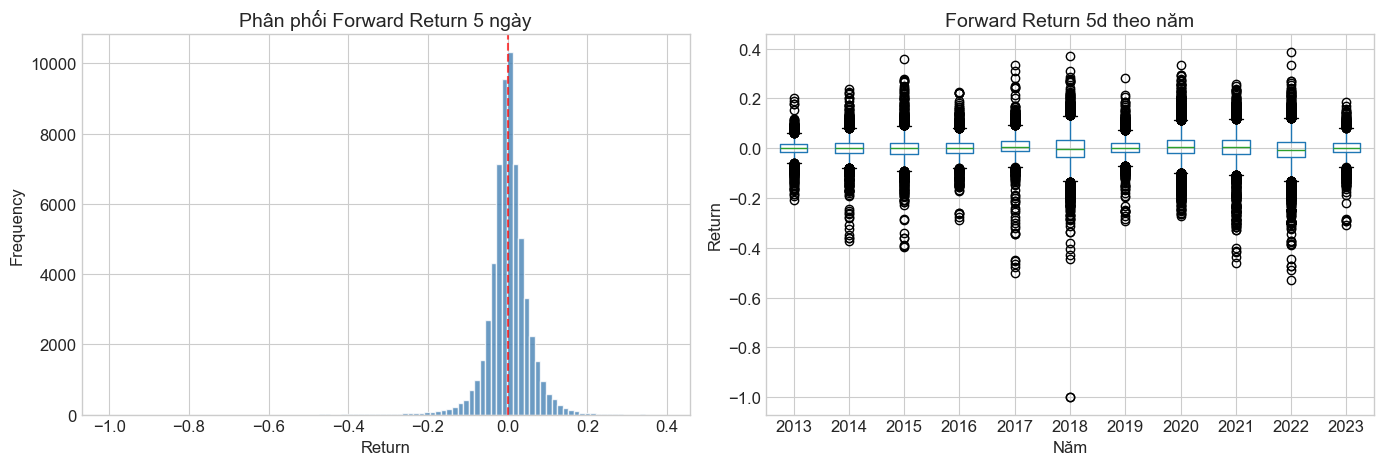

In [7]:
FORWARD_DAYS = 5

df_featured['target'] = df_featured.groupby('Symbol')['Close'].transform(
    lambda x: x.shift(-FORWARD_DAYS) / x - 1
)

# ⚠️ Thay thế tất cả inf thành NaN, rồi dropna 1 lần
df_featured = df_featured.replace([np.inf, -np.inf], np.nan)

print(f"Shape trước dropna: {df_featured.shape}")
df_clean = df_featured.dropna().reset_index(drop=True)
print(f"Shape sau dropna:   {df_clean.shape}")
print(f"Thời gian: {df_clean['TradingDate'].min().date()} → {df_clean['TradingDate'].max().date()}")
print(f"\nTarget statistics:\n{df_clean['target'].describe()}")

# Vẽ phân phối target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['target'], bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title(f'Phân phối Forward Return {FORWARD_DAYS} ngày', fontsize=14)
axes[0].set_xlabel('Return')
axes[0].set_ylabel('Frequency')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.7)

df_clean['Year'] = df_clean['TradingDate'].dt.year
df_clean.boxplot(column='target', by='Year', ax=axes[1])
axes[1].set_title(f'Forward Return {FORWARD_DAYS}d theo năm', fontsize=14)
axes[1].set_xlabel('Năm')
axes[1].set_ylabel('Return')
plt.suptitle('')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
TRAIN_END = '2020-12-31'
VAL_END = '2022-06-30'

df_train = df_clean[df_clean['TradingDate'] <= TRAIN_END]
df_val = df_clean[(df_clean['TradingDate'] > TRAIN_END) & (df_clean['TradingDate'] <= VAL_END)]
df_test = df_clean[df_clean['TradingDate'] > VAL_END]

print(f"Train: {len(df_train):>6,} samples | {df_train['TradingDate'].min().date()} → {df_train['TradingDate'].max().date()}")
print(f"Val:   {len(df_val):>6,} samples | {df_val['TradingDate'].min().date()} → {df_val['TradingDate'].max().date()}")
print(f"Test:  {len(df_test):>6,} samples | {df_test['TradingDate'].min().date()} → {df_test['TradingDate'].max().date()}")

Train: 42,024 samples | 2013-04-01 → 2020-12-31
Val:   11,490 samples | 2021-01-04 → 2022-06-30
Test:   7,620 samples | 2022-07-01 → 2023-06-23


In [9]:
# Chuẩn bị features
FEATURE_COLS = [c for c in df_clean.columns 
                if c not in ['Symbol', 'TradingDate', 'Open', 'High', 'Low', 'Close', 'Volume', 'target', 'Year']]

print(f"Số features: {len(FEATURE_COLS)}")

X_train, y_train = df_train[FEATURE_COLS].values, df_train['target'].values
X_val, y_val = df_val[FEATURE_COLS].values, df_val['target'].values
X_test, y_test = df_test[FEATURE_COLS].values, df_test['target'].values

Số features: 35


In [10]:
# StandardScaler: fit trên Train, transform lên Val/Test
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Xử lý inf/nan
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_val = np.nan_to_num(X_val, nan=0.0, posinf=0.0, neginf=0.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

# Chuyển sang PyTorch Tensor
def to_tensor(X, y):
    return (torch.FloatTensor(X).to(device), 
            torch.FloatTensor(y).reshape(-1, 1).to(device))

X_train_t, y_train_t = to_tensor(X_train, y_train)
X_val_t, y_val_t = to_tensor(X_val, y_val)
X_test_t, y_test_t = to_tensor(X_test, y_test)

In [11]:
BATCH_SIZE = 256
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)

print(f"\nX_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")
print(f"Device: {device}")


X_train: (42024, 35) | X_val: (11490, 35) | X_test: (7620, 35)
Device: cpu


In [12]:
class MLP(nn.Module):
    """
    Multi-Layer Perceptron: Input → 128 → 64 → 32 → 1
    Hỗ trợ tính L1 loss và Sparsity Ratio.
    """
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout=0.1):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.BatchNorm1d(h)]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)
    
    def get_l1_loss(self):
        """Tổng |weights| của tất cả layers."""
        return sum(torch.sum(torch.abs(p)) for p in self.parameters())
    
    def get_sparsity_ratio(self, threshold=1e-4):
        """Tỉ lệ weights ≈ 0."""
        total = sum(p.numel() for p in self.parameters())
        near_zero = sum((p.abs() < threshold).sum().item() for p in self.parameters())
        return near_zero / total if total > 0 else 0

input_dim = len(FEATURE_COLS)
print(f"Architecture: {input_dim} → 128 → 64 → 32 → 1")
print(f"Total params: {sum(p.numel() for p in MLP(input_dim).parameters()):,}")

Architecture: 35 → 128 → 64 → 32 → 1
Total params: 15,425


In [13]:
def train_model(model, train_loader, X_val_t, y_val_t, 
                epochs=200, lr=0.001, l1_lambda=0.0, 
                patience=20, model_name="Model"):
    """
    Huấn luyện MLP với early stopping.
    l1_lambda=0 → Dense MLP | l1_lambda>0 → Sparse MLP
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_epoch = 0
    best_state = None
    no_improve = 0
    
    print(f"\n{'='*60}")
    print(f"🚀 {model_name} | L1 λ = {l1_lambda}")
    print(f"{'='*60}")
    
    for epoch in range(epochs):
        # --- Train ---
        model.train()
        epoch_loss = 0
        n_batches = 0
        for X_b, y_b in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_b)
            mse_loss = criterion(y_pred, y_b)
            total_loss = mse_loss + l1_lambda * model.get_l1_loss() if l1_lambda > 0 else mse_loss
            total_loss.backward()
            optimizer.step()
            epoch_loss += mse_loss.item()
            n_batches += 1
        
        train_losses.append(epoch_loss / n_batches)
        
        # --- Validation ---
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        val_losses.append(val_loss)
        
        # --- Early stopping ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        
        if (epoch + 1) % 20 == 0 or epoch == 0:
            sp = model.get_sparsity_ratio() if l1_lambda > 0 else 0
            print(f"  Epoch {epoch+1:3d}/{epochs} | Train: {train_losses[-1]:.6f} | Val: {val_loss:.6f} | Sparsity: {sp:.1%}")
        
        if no_improve >= patience:
            print(f"  ⏹️ Early stop at epoch {epoch+1} (best: {best_epoch+1})")
            break
    
    model.load_state_dict(best_state)
    print(f"  Best epoch: {best_epoch+1} | Val MSE: {best_val_loss:.6f}")
    return model, train_losses, val_losses

In [14]:
dense_model = MLP(input_dim).to(device)
dense_model, dense_train_losses, dense_val_losses = train_model(
    dense_model, train_loader, X_val_t, y_val_t,
    epochs=200, lr=0.001, l1_lambda=0.0, patience=20,
    model_name="Dense MLP (Baseline)"
)


🚀 Dense MLP (Baseline) | L1 λ = 0.0
  Epoch   1/200 | Train: 0.043729 | Val: 0.005058 | Sparsity: 0.0%
  Epoch  20/200 | Train: 0.002417 | Val: 0.003459 | Sparsity: 0.0%
  ⏹️ Early stop at epoch 24 (best: 4)
  Best epoch: 4 | Val MSE: 0.003409


In [15]:
L1_LAMBDAS = [1e-5, 1e-4, 1e-3]
lambda_results = {}

for lam in L1_LAMBDAS:
    m = MLP(input_dim).to(device)
    m, _, _ = train_model(m, train_loader, X_val_t, y_val_t,
                          epochs=200, lr=0.001, l1_lambda=lam, patience=20,
                          model_name=f"Sparse MLP (λ={lam})")
    m.eval()
    with torch.no_grad():
        val_mse = nn.MSELoss()(m(X_val_t), y_val_t).item()
    lambda_results[lam] = {'val_mse': val_mse, 'sparsity': m.get_sparsity_ratio()}
    print(f"  → Val MSE: {val_mse:.6f} | Sparsity: {m.get_sparsity_ratio():.1%}")

best_lambda = min(lambda_results, key=lambda k: lambda_results[k]['val_mse'])
print(f"\n🏆 Best λ = {best_lambda} | Val MSE = {lambda_results[best_lambda]['val_mse']:.6f}")


🚀 Sparse MLP (λ=1e-05) | L1 λ = 1e-05
  Epoch   1/200 | Train: 0.057961 | Val: 0.006543 | Sparsity: 0.2%
  Epoch  20/200 | Train: 0.002429 | Val: 0.003433 | Sparsity: 29.9%
  ⏹️ Early stop at epoch 28 (best: 8)
  Best epoch: 8 | Val MSE: 0.003407
  → Val MSE: 0.003407 | Sparsity: 7.0%

🚀 Sparse MLP (λ=0.0001) | L1 λ = 0.0001
  Epoch   1/200 | Train: 0.044254 | Val: 0.004843 | Sparsity: 1.3%
  Epoch  20/200 | Train: 0.002405 | Val: 0.003432 | Sparsity: 87.1%
  Epoch  40/200 | Train: 0.002418 | Val: 0.003415 | Sparsity: 66.2%
  ⏹️ Early stop at epoch 44 (best: 24)
  Best epoch: 24 | Val MSE: 0.003397
  → Val MSE: 0.003397 | Sparsity: 89.6%

🚀 Sparse MLP (λ=0.001) | L1 λ = 0.001
  Epoch   1/200 | Train: 0.052400 | Val: 0.005534 | Sparsity: 7.9%
  Epoch  20/200 | Train: 0.002411 | Val: 0.003405 | Sparsity: 60.9%
  Epoch  40/200 | Train: 0.002411 | Val: 0.003404 | Sparsity: 56.7%
  ⏹️ Early stop at epoch 46 (best: 26)
  Best epoch: 26 | Val MSE: 0.003400
  → Val MSE: 0.003400 | Sparsity: 5

In [16]:
sparse_model = MLP(input_dim).to(device)
sparse_model, sparse_train_losses, sparse_val_losses = train_model(
    sparse_model, train_loader, X_val_t, y_val_t,
    epochs=200, lr=0.001, l1_lambda=best_lambda, patience=20,
    model_name=f"Sparse MLP (λ={best_lambda})"
)


🚀 Sparse MLP (λ=0.0001) | L1 λ = 0.0001
  Epoch   1/200 | Train: 0.033157 | Val: 0.004192 | Sparsity: 1.5%
  Epoch  20/200 | Train: 0.002430 | Val: 0.003415 | Sparsity: 88.6%
  Epoch  40/200 | Train: 0.002411 | Val: 0.003407 | Sparsity: 62.5%
  ⏹️ Early stop at epoch 41 (best: 21)
  Best epoch: 21 | Val MSE: 0.003390


In [17]:
def evaluate_model(model, X_t, y_t, y_np, name="Model"):
    model.eval()
    with torch.no_grad():
        y_pred = model(X_t).cpu().numpy().flatten()
    
    mse = mean_squared_error(y_np, y_pred)
    rmse = np.sqrt(mse)
    ic = np.corrcoef(y_np, y_pred)[0, 1]
    sparsity = model.get_sparsity_ratio()
    
    print(f"\n📊 {name}:")
    print(f"  MSE:      {mse:.6f}")
    print(f"  RMSE:     {rmse:.6f}")  
    print(f"  IC:       {ic:.4f}")
    print(f"  Sparsity: {sparsity:.1%}")
    
    return {'name': name, 'mse': mse, 'rmse': rmse, 'ic': ic, 
            'sparsity': sparsity, 'y_pred': y_pred, 'y_true': y_np}

dense_res = evaluate_model(dense_model, X_test_t, y_test_t, y_test, "Dense MLP")
sparse_res = evaluate_model(sparse_model, X_test_t, y_test_t, y_test, "Sparse MLP")


📊 Dense MLP:
  MSE:      0.003180
  RMSE:     0.056396
  IC:       -0.0088
  Sparsity: 0.1%

📊 Sparse MLP:
  MSE:      0.003135
  RMSE:     0.055995
  IC:       0.0390
  Sparsity: 87.7%


In [18]:
print("\n" + "=" * 55)
print("         BẢNG SO SÁNH KẾT QUẢ (TEST SET)")
print("=" * 55)
print(f"{'Metric':<18} {'Dense MLP':>15} {'Sparse MLP':>15}")
print("-" * 55)
print(f"{'MSE':<18} {dense_res['mse']:>15.6f} {sparse_res['mse']:>15.6f}")
print(f"{'RMSE':<18} {dense_res['rmse']:>15.6f} {sparse_res['rmse']:>15.6f}")
print(f"{'IC':<18} {dense_res['ic']:>15.4f} {sparse_res['ic']:>15.4f}")
print(f"{'Sparsity Ratio':<18} {dense_res['sparsity']:>14.1%} {sparse_res['sparsity']:>14.1%}")
print("=" * 55)


         BẢNG SO SÁNH KẾT QUẢ (TEST SET)
Metric                   Dense MLP      Sparse MLP
-------------------------------------------------------
MSE                       0.003180        0.003135
RMSE                      0.056396        0.055995
IC                         -0.0088          0.0390
Sparsity Ratio               0.1%          87.7%


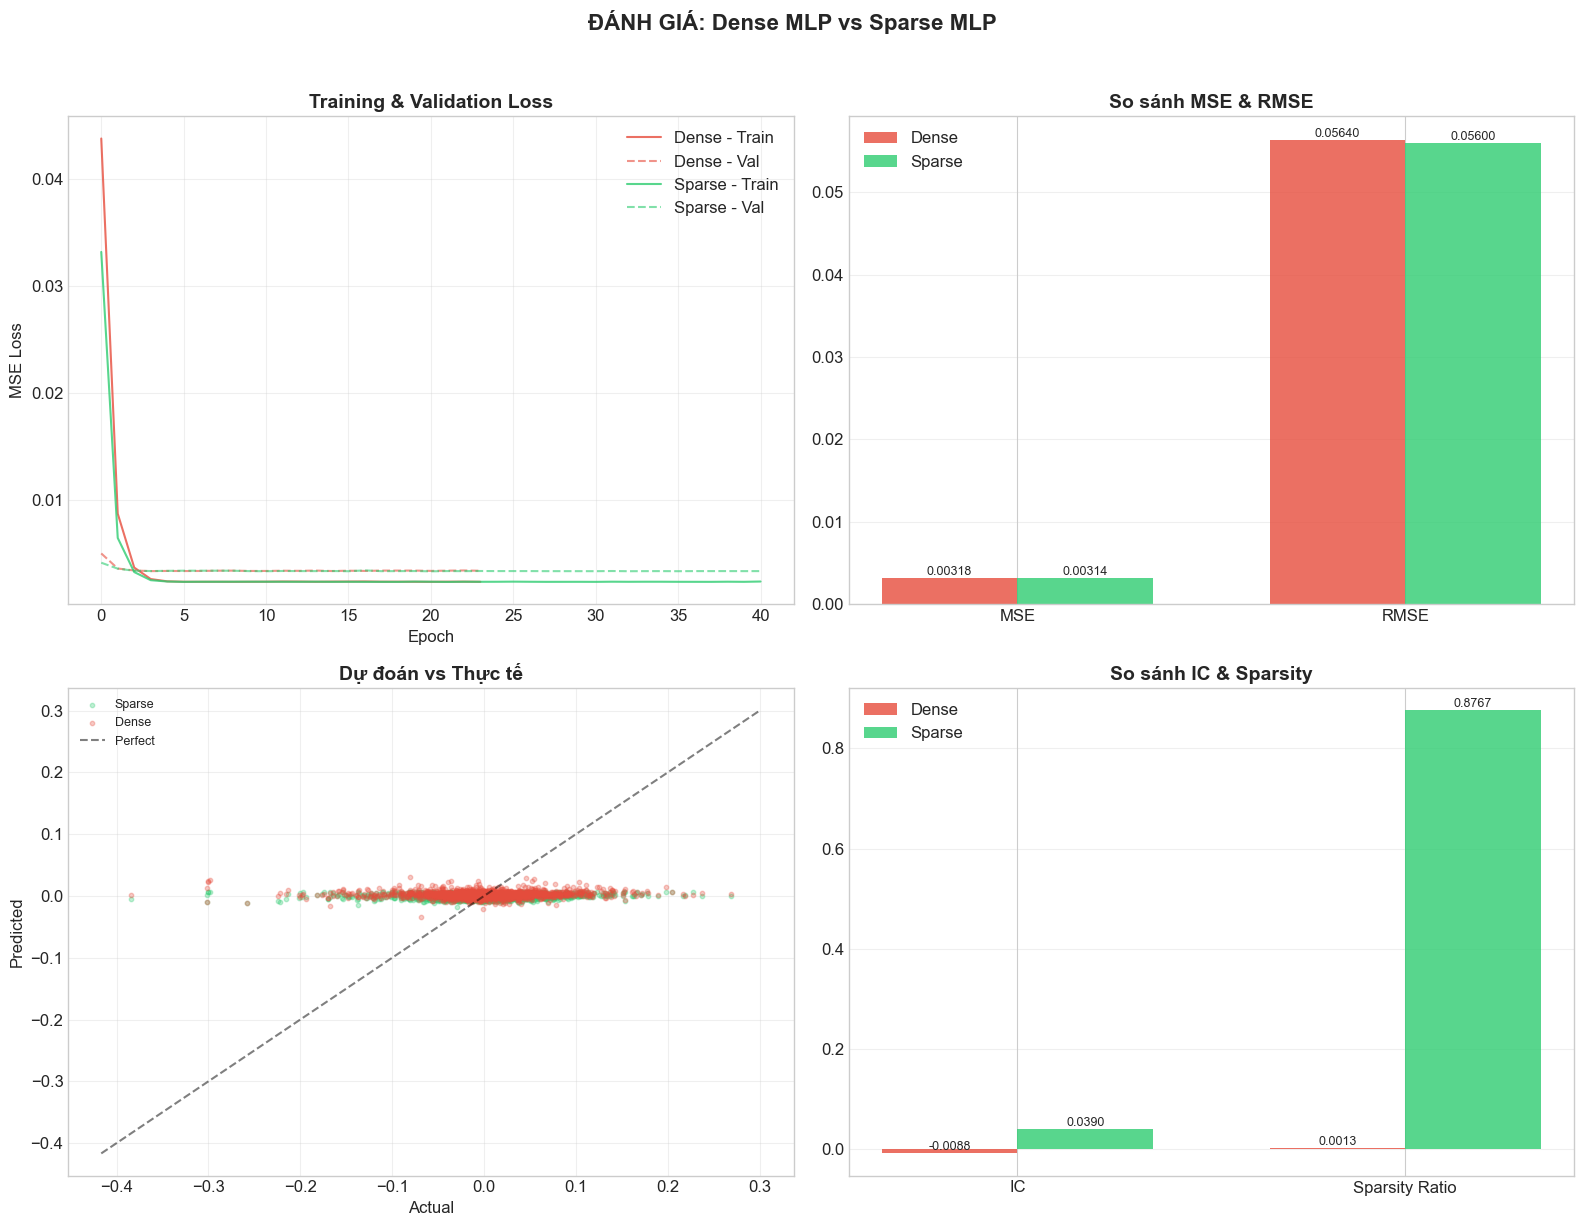

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Training Loss Curve
ax = axes[0, 0]
ax.plot(dense_train_losses, label='Dense - Train', color='#E74C3C', alpha=0.8)
ax.plot(dense_val_losses, label='Dense - Val', color='#E74C3C', ls='--', alpha=0.6)
ax.plot(sparse_train_losses, label='Sparse - Train', color='#2ECC71', alpha=0.8)
ax.plot(sparse_val_losses, label='Sparse - Val', color='#2ECC71', ls='--', alpha=0.6)
ax.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# 2. MSE & RMSE Bar Chart
ax = axes[0, 1]
x = np.arange(2); w = 0.35
b1 = ax.bar(x - w/2, [dense_res['mse'], dense_res['rmse']], w, label='Dense', color='#E74C3C', alpha=0.8)
b2 = ax.bar(x + w/2, [sparse_res['mse'], sparse_res['rmse']], w, label='Sparse', color='#2ECC71', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(['MSE', 'RMSE'])
ax.set_title('So sánh MSE & RMSE', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for b in b1: ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'{b.get_height():.5f}', ha='center', va='bottom', fontsize=9)
for b in b2: ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'{b.get_height():.5f}', ha='center', va='bottom', fontsize=9)

# 3. Scatter: Predicted vs Actual
ax = axes[1, 0]
idx = np.random.choice(len(y_test), min(2000, len(y_test)), replace=False)
ax.scatter(sparse_res['y_true'][idx], sparse_res['y_pred'][idx], alpha=0.3, s=10, c='#2ECC71', label='Sparse')
ax.scatter(dense_res['y_true'][idx], dense_res['y_pred'][idx], alpha=0.3, s=10, c='#E74C3C', label='Dense')
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', alpha=0.5, label='Perfect')
ax.set_title('Dự đoán vs Thực tế', fontsize=14, fontweight='bold')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 4. IC & Sparsity
ax = axes[1, 1]
b1 = ax.bar(x - w/2, [dense_res['ic'], dense_res['sparsity']], w, label='Dense', color='#E74C3C', alpha=0.8)
b2 = ax.bar(x + w/2, [sparse_res['ic'], sparse_res['sparsity']], w, label='Sparse', color='#2ECC71', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(['IC', 'Sparsity Ratio'])
ax.set_title('So sánh IC & Sparsity', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for b in b1: ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for b in b2: ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('ĐÁNH GIÁ: Dense MLP vs Sparse MLP', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
def get_feature_importance(model, feature_names):
    """Feature importance = tổng |weights| từ input layer."""
    for module in model.network:
        if isinstance(module, nn.Linear):
            weights = module.weight.data.cpu().numpy()
            break
    importance = np.sum(np.abs(weights), axis=0)
    fi = pd.DataFrame({'feature': feature_names, 'importance': importance})
    return fi.sort_values('importance', ascending=False).reset_index(drop=True), weights

dense_fi, dense_w = get_feature_importance(dense_model, FEATURE_COLS)
sparse_fi, sparse_w = get_feature_importance(sparse_model, FEATURE_COLS)

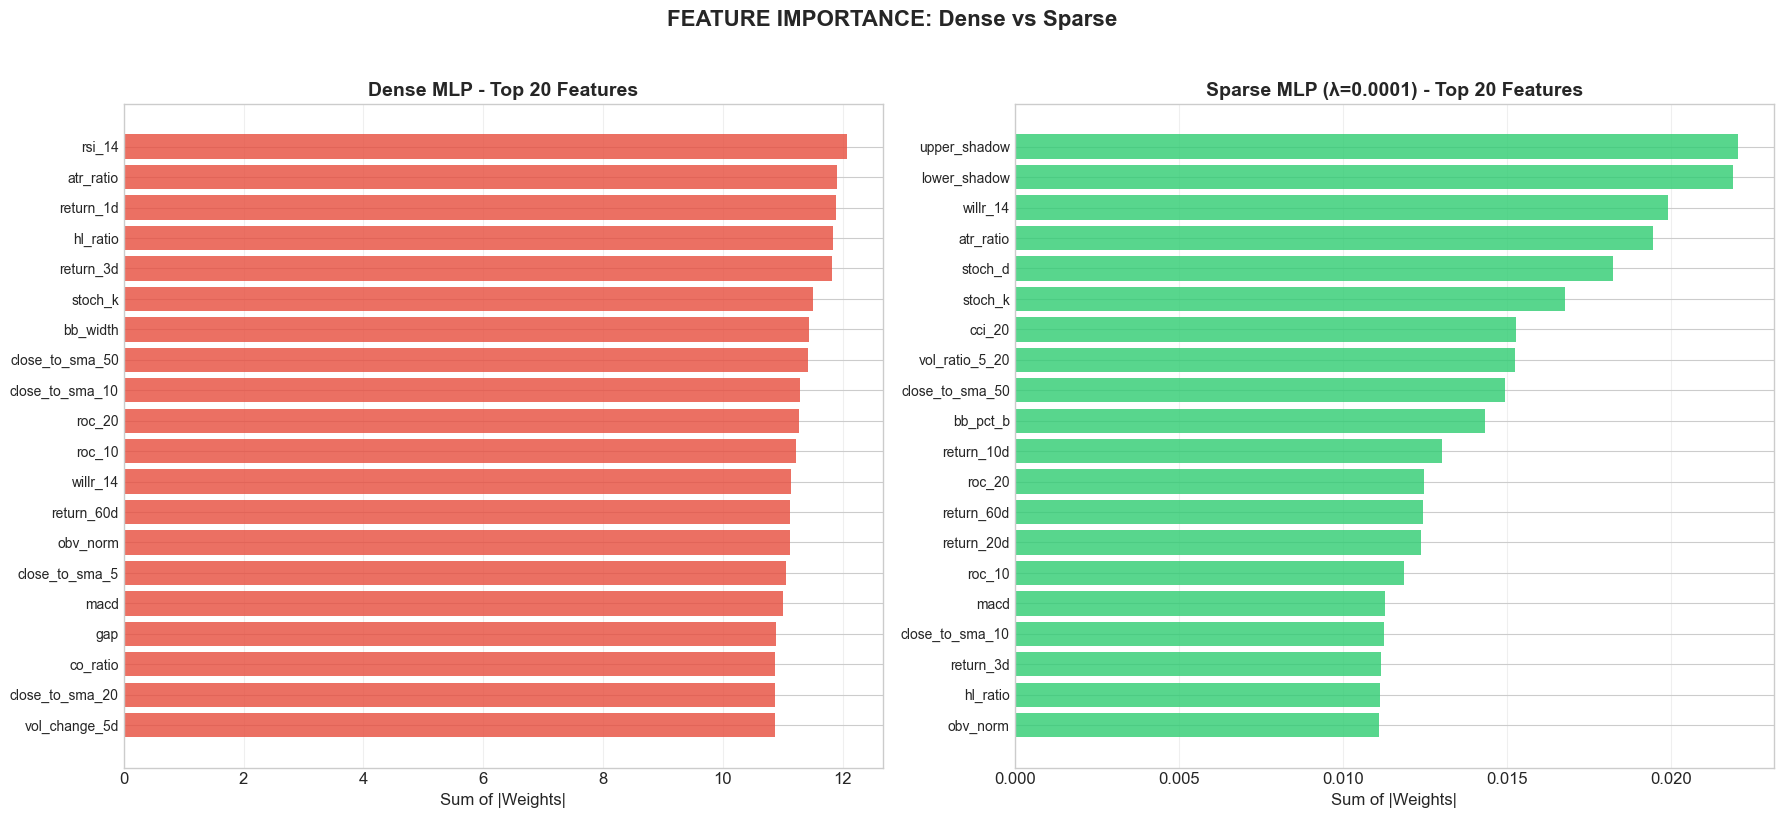

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
top_n = 20

for ax, fi, title, color in [
    (axes[0], dense_fi, 'Dense MLP', '#E74C3C'),
    (axes[1], sparse_fi, f'Sparse MLP (λ={best_lambda})', '#2ECC71')
]:
    top = fi.head(top_n)
    ax.barh(range(top_n), top['importance'].values, color=color, alpha=0.8)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top['feature'].values, fontsize=10)
    ax.invert_yaxis()
    ax.set_title(f'{title} - Top {top_n} Features', fontsize=14, fontweight='bold')
    ax.set_xlabel('Sum of |Weights|')
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('FEATURE IMPORTANCE: Dense vs Sparse', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Top 10 features với giải thích tài chính
explanations = {
    'return_1d': 'Momentum 1 ngày', 'return_3d': 'Momentum 3 ngày',
    'return_5d': 'Momentum tuần', 'return_10d': 'Momentum 2 tuần',
    'return_20d': 'Momentum tháng', 'return_60d': 'Momentum quý',
    'roc_5': 'Tốc độ thay đổi giá 5d', 'roc_10': 'Tốc độ thay đổi 10d',
    'roc_20': 'Tốc độ thay đổi 20d',
    'rsi_14': 'Trạng thái quá mua/bán (14d)', 'rsi_7': 'RSI ngắn hạn',
    'macd': 'Xu hướng momentum', 'macd_signal': 'Tín hiệu MACD',
    'macd_hist': 'Sức mạnh xu hướng',
    'stoch_k': 'Dao động Stochastic', 'stoch_d': 'Tín hiệu Stochastic',
    'willr_14': 'Williams %R - Quá mua/bán', 'cci_20': 'CCI',
    'atr_ratio': 'Biến động tương đối', 'bb_pct_b': 'Vị trí trong Bollinger',
    'bb_width': 'Độ rộng Bollinger', 'std_ratio': 'Biến động giá',
    'vol_ratio_5_20': 'Thay đổi khối lượng', 'vol_change_1d': 'Volume 1d',
    'vol_change_5d': 'Volume 5d', 'obv_norm': 'Dòng tiền tích lũy',
    'hl_ratio': 'Biên độ giá trong ngày', 'co_ratio': 'Xu hướng trong ngày',
    'gap': 'Gap mở cửa', 'upper_shadow': 'Bóng trên', 'lower_shadow': 'Bóng dưới',
    'close_to_sma_5': 'Giá/SMA5', 'close_to_sma_10': 'Giá/SMA10',
    'close_to_sma_20': 'Giá/SMA20', 'close_to_sma_50': 'Giá/SMA50',
}

print("\n" + "=" * 70)
print("TOP 10 FEATURES QUAN TRỌNG NHẤT (SPARSE MLP)")
print("=" * 70)
for i, row in sparse_fi.head(10).iterrows():
    exp = explanations.get(row['feature'], '')
    print(f"  {i+1:2d}. {row['feature']:<22s} | {row['importance']:.4f} | {exp}")

# Features bị loại
zero_feats = sparse_fi[sparse_fi['importance'] < 0.01]
print(f"\n📊 Features bị Sparse loại bỏ (importance < 0.01): {len(zero_feats)}/{len(FEATURE_COLS)}")



TOP 10 FEATURES QUAN TRỌNG NHẤT (SPARSE MLP)
   1. upper_shadow           | 0.0220 | Bóng trên
   2. lower_shadow           | 0.0219 | Bóng dưới
   3. willr_14               | 0.0199 | Williams %R - Quá mua/bán
   4. atr_ratio              | 0.0195 | Biến động tương đối
   5. stoch_d                | 0.0182 | Tín hiệu Stochastic
   6. stoch_k                | 0.0168 | Dao động Stochastic
   7. cci_20                 | 0.0153 | CCI
   8. vol_ratio_5_20         | 0.0153 | Thay đổi khối lượng
   9. close_to_sma_50        | 0.0149 | Giá/SMA50
  10. bb_pct_b               | 0.0143 | Vị trí trong Bollinger

📊 Features bị Sparse loại bỏ (importance < 0.01): 12/35


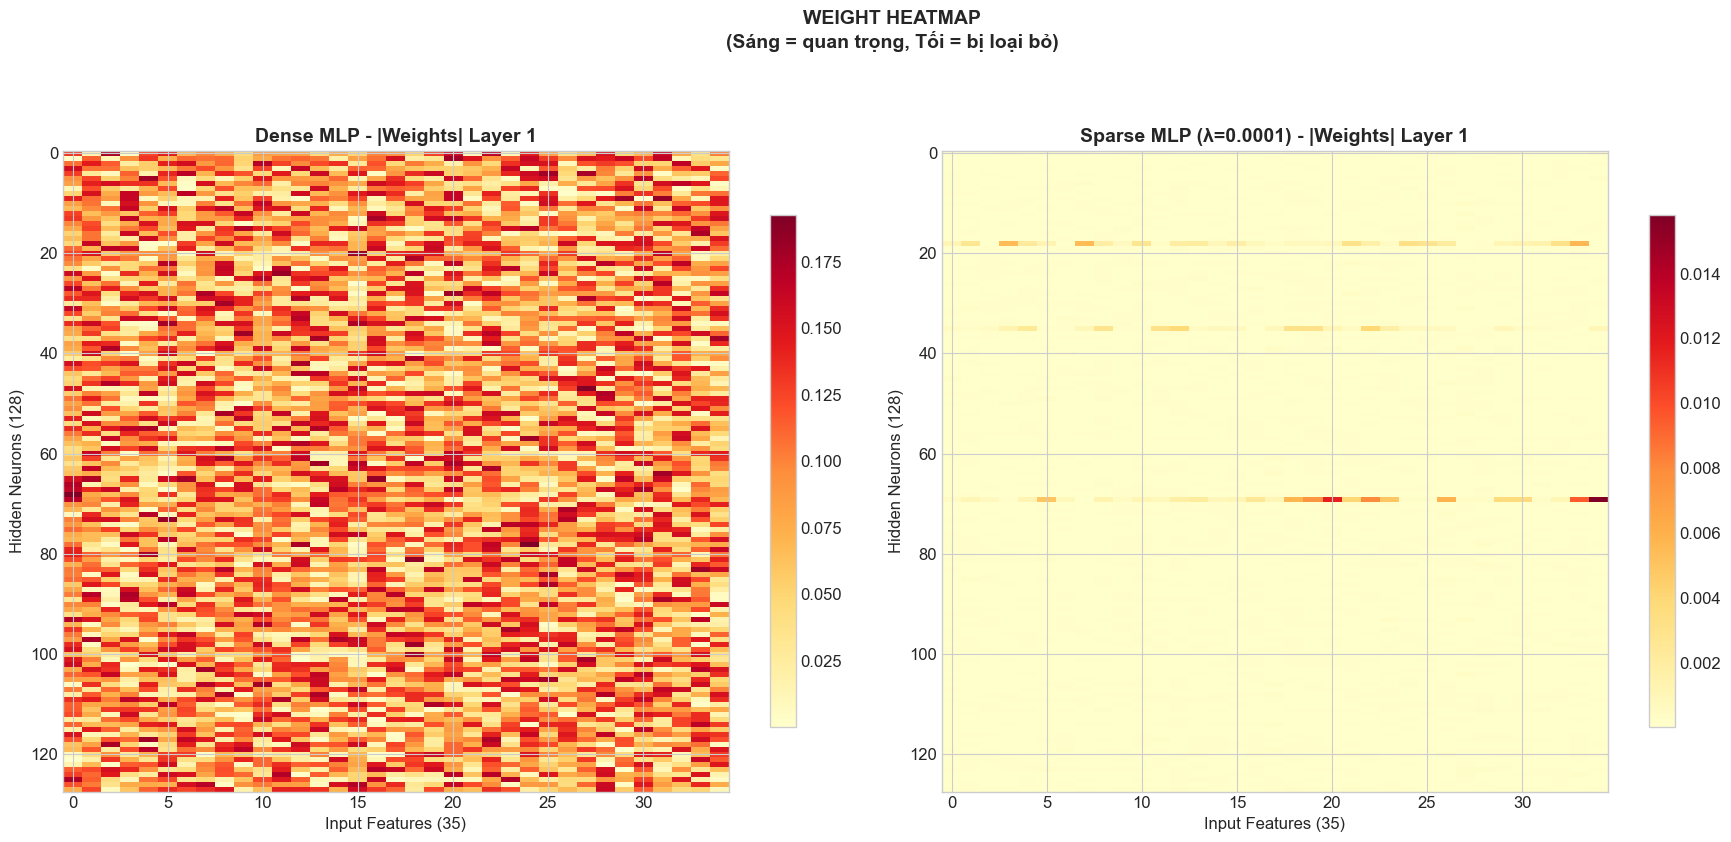

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, w, title in [
    (axes[0], dense_w, 'Dense MLP'),
    (axes[1], sparse_w, f'Sparse MLP (λ={best_lambda})')
]:
    im = ax.imshow(np.abs(w), aspect='auto', cmap='YlOrRd', interpolation='nearest')
    ax.set_title(f'{title} - |Weights| Layer 1', fontsize=14, fontweight='bold')
    ax.set_xlabel(f'Input Features ({w.shape[1]})')
    ax.set_ylabel(f'Hidden Neurons ({w.shape[0]})')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('WEIGHT HEATMAP\n(Sáng = quan trọng, Tối = bị loại bỏ)', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('weight_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

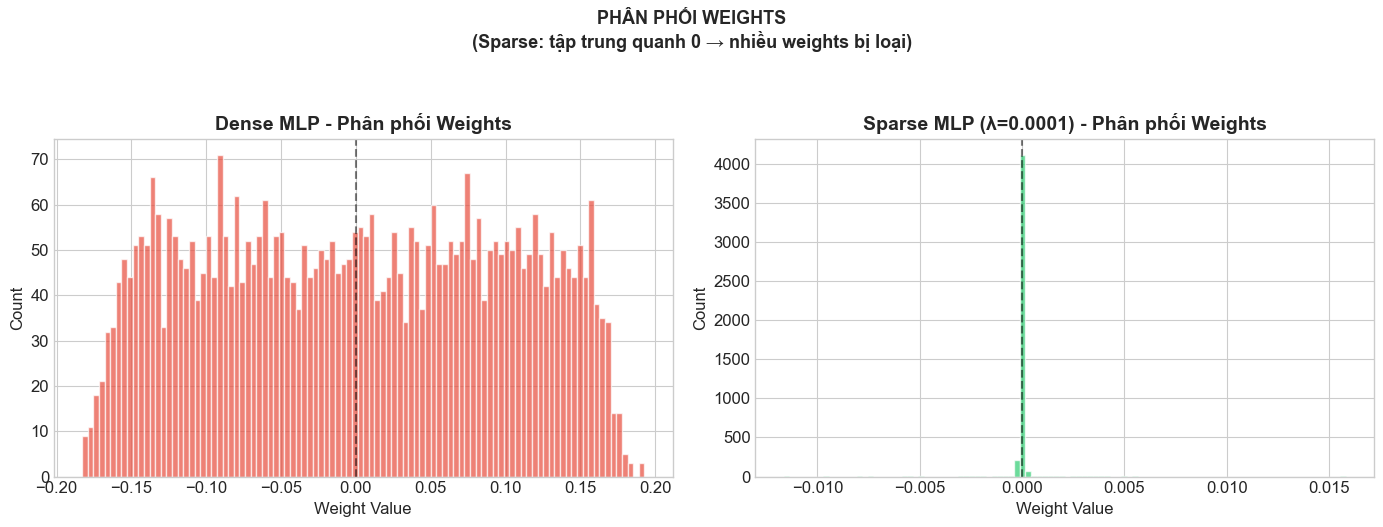

In [24]:
# Phân phối weights
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, w, title, color in [
    (axes[0], dense_w, 'Dense MLP', '#E74C3C'),
    (axes[1], sparse_w, f'Sparse MLP (λ={best_lambda})', '#2ECC71')
]:
    ax.hist(w.flatten(), bins=100, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(f'{title} - Phân phối Weights', fontsize=14, fontweight='bold')
    ax.set_xlabel('Weight Value'); ax.set_ylabel('Count')
    ax.axvline(x=0, color='black', ls='--', alpha=0.5)

plt.suptitle('PHÂN PHỐI WEIGHTS\n(Sparse: tập trung quanh 0 → nhiều weights bị loại)', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('weight_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
print("=" * 70)
print("                        TỔNG KẾT")
print("=" * 70)
print(f"""
📊 Dataset:  VN30 - 30 cổ phiếu Việt Nam (2013-2023)
📊 Features: {len(FEATURE_COLS)}
📊 Target:   Forward Return {FORWARD_DAYS} ngày

{'Metric':<18} {'Dense MLP':>12} {'Sparse MLP':>12}
{'─'*45}
{'MSE':<18} {dense_res['mse']:>12.6f} {sparse_res['mse']:>12.6f}
{'RMSE':<18} {dense_res['rmse']:>12.6f} {sparse_res['rmse']:>12.6f}
{'IC':<18} {dense_res['ic']:>12.4f} {sparse_res['ic']:>12.4f}
{'Sparsity':<18} {dense_res['sparsity']:>11.1%} {sparse_res['sparsity']:>11.1%}

🏆 Best λ: {best_lambda}
🔍 Sparse giữ lại: {len(sparse_fi[sparse_fi['importance'] >= 0.01])}/{len(FEATURE_COLS)} features

Top 5 Features (Sparse MLP):""")
for i, row in sparse_fi.head(5).iterrows():
    print(f"  {i+1}. {row['feature']}: {row['importance']:.4f}")

print(f"""
📁 Các file đã lưu:
  - target_distribution.png
  - model_comparison.png  
  - feature_importance.png
  - weight_heatmap.png
  - weight_distribution.png
""")




                        TỔNG KẾT

📊 Dataset:  VN30 - 30 cổ phiếu Việt Nam (2013-2023)
📊 Features: 35
📊 Target:   Forward Return 5 ngày

Metric                Dense MLP   Sparse MLP
─────────────────────────────────────────────
MSE                    0.003180     0.003135
RMSE                   0.056396     0.055995
IC                      -0.0088       0.0390
Sparsity                  0.1%       87.7%

🏆 Best λ: 0.0001
🔍 Sparse giữ lại: 23/35 features

Top 5 Features (Sparse MLP):
  1. upper_shadow: 0.0220
  2. lower_shadow: 0.0219
  3. willr_14: 0.0199
  4. atr_ratio: 0.0195
  5. stoch_d: 0.0182

📁 Các file đã lưu:
  - target_distribution.png
  - model_comparison.png  
  - feature_importance.png
  - weight_heatmap.png
  - weight_distribution.png



In [26]:
# %%
# SAVE MODEL & SCALER cho Web App
import pickle

# Lưu models
torch.save(dense_model.state_dict(), 'dense_model.pth')
torch.save(sparse_model.state_dict(), 'sparse_model.pth')

# Lưu scaler + metadata
metadata = {
    'scaler': scaler,
    'feature_cols': FEATURE_COLS,
    'input_dim': input_dim,
    'best_lambda': best_lambda,
    'dense_res': {k: v for k, v in dense_res.items() if k != 'y_pred' and k != 'y_true'},
    'sparse_res': {k: v for k, v in sparse_res.items() if k != 'y_pred' and k != 'y_true'},
    'dense_fi': dense_fi,
    'sparse_fi': sparse_fi,
    'dense_w': dense_w,
    'sparse_w': sparse_w,
    'vn30_symbols': VN30_SYMBOLS,
}

with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print("✅ Đã lưu:")
print("  - dense_model.pth")
print("  - sparse_model.pth")  
print("  - model_metadata.pkl")

✅ Đã lưu:
  - dense_model.pth
  - sparse_model.pth
  - model_metadata.pkl
